# &laquo;Машинное обучение&raquo;, AI Masters

### Домашняя работа №7. Методы понижения размерности, кластеризация. Пакеты для интерактивной визуализации.

In [1]:
import numpy as np
import scipy as sp
import pandas as pd

# uncomment if you need it
# import matplotlib.pyplot as plt
# import seaborn as sns

In [2]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'colab'
print("Plotly renderer set to 'colab'")

Plotly renderer set to 'colab'


### Задача 1. Подбор параметров UMAP и оценка полученной визуализации (4 балла)

Для вас загружен датасет по данным секвенирования одиночных клеток. Датасет уже предобработан, в задаче нет необходимости вникать в специфику данных (кому интересно - [источник](https://doi.org/10.1101/2021.09.16.460628) датасета).

Ваша задача:
1. (2 балла) Предобработайте ваш датасет: найдите в нем ближайших соседей одним из быстрых способов, поддерживающих sparse-данные. После этого научитесь передавать таких соседей в UMAP (изучите, что принимает на вход параметр `precomputed_knn`). Сравните полученную визуализацию с запуском класса `umap.UMAP` на sparse матрице с исходными данными.

2. (2 балла) Подберите параметры UMAP таким образом, чтобы по данным получались наилучшие кластеры из атрибута `cell_type` (см. метаданные). Придумайте <u>количественный</u> способ оценки получаемого пространства (известная разметка на кластеры в этом пространстве должна быть хорошей). Попробуйте различные параметры UMAP и добейтесь улучшения вашей функции качества относительно запуска с параметрами по умолчанию.

Бонусные баллы будут ставиться за:
* Хорошую работу, оформление выводов.
* Понятную визуализацию, сравнение, интерактивные графики (если они уместны).
* Учет в получаемой 2D-структуре дополнительной информации из метаданных.
* Все остальные правила из семинара 1 тоже действуют :)

<font color='red'>**Обязательно**</font>: в конце задания продемонстрируйте полученный график / графики и сравните с дефолтными настройками! Если вы делали дополнительную работу, также кратко опишите, что было сделано и продемонстрируйте, что это работает! При проверке мы не сможем проверять ваш код на предмет наличия скрытого (или не очень скрытого) функционала, поэтому **вы не получите доп. баллы, если не покажете, как работает сделанная вами фишка**.

In [3]:
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/singlecell/expression_data.npz -O expression_data.npz 2> /dev/null
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/singlecell/metadata_row.parquet -O metadata_row.parquet 2> /dev/null
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/singlecell/metadata_col.parquet -O metadata_col.parquet 2> /dev/null

In [4]:
data = sp.sparse.load_npz('expression_data.npz')
meta_row = pd.read_parquet('metadata_row.parquet')
meta_col = pd.read_parquet('metadata_col.parquet')
data.shape, meta_row.shape, meta_col.shape

((50753, 1000), (50753, 4), (1000, 2))

In [5]:
meta_row

,donor_id,disease,tissue,cell_type
Fimbria1_AAACGAAGTATCTCGA,donor_1,normal,fimbria of fallopian tube,secretory cell
Fimbria1_AAACGCTGTCAGGTAG,donor_1,normal,fimbria of fallopian tube,secretory cell
Fimbria1_AAAGAACGTGACACAG,donor_1,normal,fimbria of fallopian tube,ciliated epithelial cell
Fimbria1_AAAGAACTCCCGAACG,donor_1,normal,fimbria of fallopian tube,blood vessel endothelial cell
Fimbria1_AAAGAACTCCTTATCA,donor_1,normal,fimbria of fallopian tube,mature NK T cell
...,...,...,...,...
FT4_TTTGTTGCAGCTCATA-1,donor_4,normal,fallopian tube,macrophage
FT4_TTTGTTGGTAGACAGC-1,donor_4,normal,fallopian tube,macrophage
FT4_TTTGTTGGTCAAGCGA-1,donor_4,normal,fallopian tube,myofibroblast cell
FT4_TTTGTTGGTCGCGTCA-1,donor_4,normal,fallopian tube,endothelial cell of lymphatic vessel


In [6]:
meta_row.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50753 entries, Fimbria1_AAACGAAGTATCTCGA to FT4_TTTGTTGTCGACACTA-1
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   donor_id   50753 non-null  category
 1   disease    50753 non-null  category
 2   tissue     50753 non-null  category
 3   cell_type  50753 non-null  category
dtypes: category(4)
memory usage: 595.7+ KB


In [7]:
meta_col

,feature_name,feature_type
ENSG00000000938,FGR,protein_coding
ENSG00000002933,TMEM176A,protein_coding
ENSG00000003436,TFPI,protein_coding
ENSG00000004776,HSPB6,protein_coding
ENSG00000004799,PDK4,protein_coding
...,...,...
ENSG00000283063,TRBV6-2,TR_V_gene
ENSG00000283674,ENSG00000283674,lncRNA
ENSG00000283697,HSFX3,protein_coding
ENSG00000286122,LINC02964,lncRNA


### Задание 1.1

In [8]:
import umap

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
normal_umap = umap.UMAP(n_components=2, n_jobs=-1, verbose=10, n_neighbors=5, random_state=42)
normal_umap.fit(data, y=LabelEncoder().fit_transform(meta_row['cell_type']))

/home/i3alumba/Projects/AI/ML/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP(n_jobs=1, n_neighbors=5, random_state=42, verbose=10)
Fri Dec 26 18:28:11 2025 Construct fuzzy simplicial set
Fri Dec 26 18:28:11 2025 Finding Nearest Neighbors
Fri Dec 26 18:28:11 2025 Building RP forest with 16 trees
Fri Dec 26 18:29:13 2025 metric NN descent for 16 iterations
	 1  /  16
	 2  /  16
	 3  /  16
	 4  /  16
	 5  /  16
	 6  /  16
	 7  /  16
	Stopping threshold met -- exiting after 7 iterations
Fri Dec 26 18:29:37 2025 Finished Nearest Neighbor Search
Fri Dec 26 18:29:39 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Fri Dec 26 18:30:00 2025 Finished embedding


,n_neighbors,5
,n_components,2
,metric,'euclidean'
,metric_kwds,None
,output_metric,'euclidean'
,output_metric_kwds,None
,n_epochs,None
,learning_rate,1.0
,init,'spectral'
,min_dist,0.1
,spread,1.0


In [11]:
import pandas
import matplotlib 
import datashader

In [12]:
from warnings import filterwarnings
filterwarnings('ignore')

from umap.plot import points

<Axes: >

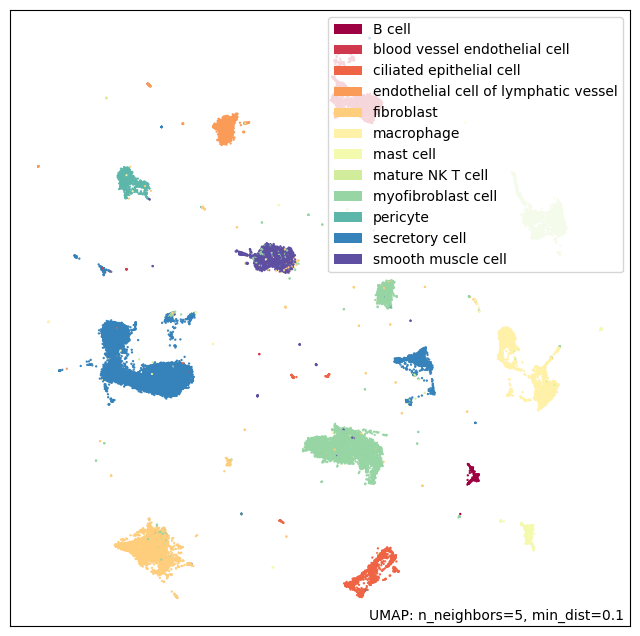

In [13]:
umap.plot.points(normal_umap, labels=meta_row['cell_type'])

In [14]:
import nmslib

Your CPU supports instructions that this binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2
For maximum performance, you can install NMSLIB from sources 
pip install --no-binary :all: nmslib


In [15]:
index = nmslib.init(method='hnsw', space='cosinesimil_sparse', data_type=nmslib.DataType.SPARSE_VECTOR)
index.addDataPointBatch(data)
index.createIndex()

In [16]:
query = data

In [17]:
neighbors = index.knnQueryBatch(query, k=5)

In [18]:
indices, distances = zip(*neighbors)

In [19]:
indices = np.asarray(list(indices))
distances = np.asarray(list(distances))

In [20]:
precomputed_umap = umap.UMAP(n_components=2, n_jobs=-1, verbose=10, n_neighbors=5, precomputed_knn=(indices, distances), random_state=42)
precomputed_umap.fit(data, y=LabelEncoder().fit_transform(meta_row['cell_type']))

UMAP(n_jobs=1, n_neighbors=5, precomputed_knn=(array([[    0, 21020, 4229, 2323, 7372],
       [    1, 2473, 165, 991, 6559],
       [    2, 3689, 32328, 425, 29417],
       ...,
       [50750, 44943, 48954, 49314, 50044],
       [50751, 46980, 50620, 44300, 48270],
       [50752, 47718, 49302, 49411, 50195]], shape=(50753, 5), dtype=int32), array([[0.        , 0.17484063, 0.18059099, 0.18235725, 0.18267304],
       [0.        , 0.15360165, 0.16647536, 0.18749976, 0.19059998],
       [0.        , 0.11445439, 0.11774284, 0.11843497, 0.11866146],
       ...,
       [0.        , 0.17293662, 0.17633003, 0.1780582 , 0.1816693 ],
       [0.        , 0.1926412 , 0.19949406, 0.20632952, 0.22164917],
       [0.        , 0.13577265, 0.1405949 , 0.14548504, 0.1471867 ]],
      shape=(50753, 5), dtype=float32)), random_state=42, verbose=10)
Fri Dec 26 18:30:16 2025 Construct fuzzy simplicial set
Fri Dec 26 18:30:16 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Fri Dec 26 18:30:38 2025 Finished embedding


,n_neighbors,5
,n_components,2
,metric,'euclidean'
,metric_kwds,None
,output_metric,'euclidean'
,output_metric_kwds,None
,n_epochs,None
,learning_rate,1.0
,init,'spectral'
,min_dist,0.1
,spread,1.0


<Axes: >

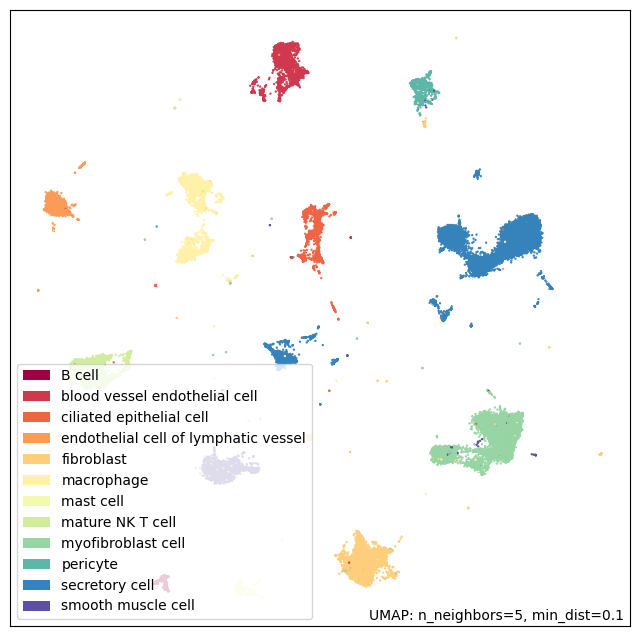

In [21]:
umap.plot.points(precomputed_umap, labels=meta_row['cell_type'])

Получились совершенно другие по форме кластеры, но уровню "зашумлённости" почти то же самое, что говорит о хорошем качестве снижения размерности - метриеские соотношения сохранены настолько насколько это возможно

### Задание 1.2

Данные уже размечены, поэтому можно использовать модели обучения с учителем. Будем использовать KNN-классификатор в исходном и двумермом пространстве для оценки качества снижения размерности относительно качества классифиактора в исходном пространстве. Целевая метрика - точность. Таким образом, мы проверяем насколько объекты одного класса остаются близко друг к другу - использовать KNN логично с учётом предыдущих визуализаций где мы наблюдаем несколько явно выделенных кластеров

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


def objective(params):
    n_neighbors = params['n_neighbors']
    neighbors = index.knnQueryBatch(data, k=n_neighbors)
    indices, distances = zip(*neighbors)
    indices = np.asarray(list(indices))
    distances = np.asarray(list(distances))
    mapper = umap.UMAP(n_components=2, n_jobs=-1,
                       precomputed_knn=(indices, distances), **params)
    mapper.fit(data, y=LabelEncoder().fit_transform(meta_row['cell_type']))
    data_transformed = mapper.transform(data)

    def score_knn(X):
        X_train, X_test, y_train, y_test = train_test_split(
            X, meta_row['cell_type'])

        knn = KNeighborsClassifier(n_jobs=-1, n_neighbors=n_neighbors)

        knn.fit(X_train, y_train)
        y_pred_1 = knn.predict(X_test)

        acc = accuracy_score(y_test, y_pred_1)
        return acc

    score_orig = score_knn(data)
    score_red = score_knn(data_transformed)

    return score_red, score_orig

In [23]:
import optuna


def target(trial: optuna.Trial):  
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 2, 30),
        "min_dist": trial.suggest_float("min_dist", 0.0, 0.99),
        
        "n_epochs": trial.suggest_int("n_epochs", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1.0, log=True),
        "init": trial.suggest_categorical("init", ["spectral", "random"]),
        
        "set_op_mix_ratio": trial.suggest_float("set_op_mix_ratio", 0.0, 1.0),
        "local_connectivity": trial.suggest_float("local_connectivity", 1.0, 5.0),
        "repulsion_strength": trial.suggest_float("repulsion_strength", 0.5, 2.0),
        "negative_sample_rate": trial.suggest_int("negative_sample_rate", 5, 20),
        
        "low_memory": True,
    }
    score_red, score_orig = objective(params)
    return -np.log(score_red) + np.log(score_orig)

In [24]:
study = optuna.create_study()

[I 2025-12-26 18:30:39,889] A new study created in memory with name: no-name-d23f1eba-4724-4bc3-ad4f-14cf165d39e2


In [25]:
study.optimize(target, n_trials=30, show_progress_bar=True, n_jobs=2)

  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-26 18:31:43,202] Trial 1 finished with value: -0.013781022250023152 and parameters: {'n_neighbors': 7, 'min_dist': 0.87232445619316, 'n_epochs': 372, 'learning_rate': 0.012909916670341607, 'init': 'spectral', 'set_op_mix_ratio': 0.40503496733271116, 'local_connectivity': 4.9979406753757765, 'repulsion_strength': 0.693527437787916, 'negative_sample_rate': 10}. Best is trial 1 with value: -0.013781022250023152.
[I 2025-12-26 18:32:54,892] Trial 0 finished with value: -0.03043468135006694 and parameters: {'n_neighbors': 21, 'min_dist': 0.5297186592048263, 'n_epochs': 306, 'learning_rate': 0.32533941322204935, 'init': 'spectral', 'set_op_mix_ratio': 0.05238481616617563, 'local_connectivity': 1.7459380886997855, 'repulsion_strength': 1.9958453188246117, 'negative_sample_rate': 18}. Best is trial 0 with value: -0.03043468135006694.
[I 2025-12-26 18:33:42,011] Trial 2 finished with value: -0.010973489509761552 and parameters: {'n_neighbors': 3, 'min_dist': 0.4487786018644895, 'n_ep

In [28]:
best_params = study.best_params

In [30]:
print(best_params)

{'n_neighbors': 27, 'min_dist': 0.572737538961062, 'n_epochs': 770, 'learning_rate': 0.046814659706912815, 'init': 'spectral', 'set_op_mix_ratio': 0.17965146487100475, 'local_connectivity': 1.3691177660679825, 'repulsion_strength': 1.540557416398203, 'negative_sample_rate': 7}


In [29]:
score1, score2 = objective(best_params)

In [31]:
score1/score2

1.0291072156543009

Видно что качество классификаци выросло на 2 процента после уменьшения размерности. Теперь посмотри на показатели дефолтных параметров:

In [33]:
score1, score2 = objective({'n_neighbors': 5})

In [34]:
score1/score2

1.0226288701903439

Действительно, есть небольшой прирост

### Задача 2. **Tool**: оценка стабильности кластеров, получаемых выбранным методом DR (6 баллов)

Напишите класс `DimRedValidator`, которая будет производить оценку стабильности кластеров, получаемых с помощью метода снижения размерности (выберите один из рассмотренных на семинаре: t-SNE, UMAP, PaCMAP, LocalMAP).

При инициализации класс должен принимать на вход:
* Класс или функцию для обучения эмбеддинга (т.к. разные фреймворки не обязательно следуют интерфейсу fit-predict Scikit-learn, сделайте возможность гибко запускать вашу функцию с эмбеддингами разных методов DR)
* Класс или функцию для обучения кластеризатора
* Параметры для эмбеддинга, кластеризатора и прочего

Какие методы **должен** поддерживать ваш класс:
* `fit` - обучает ваш класс и несколько эмбеддингов (одного типа) с заданными параметрами, но разными инициализациями и состоянием генератора псевдослучайных чисел (т.е. разными сидами)
    * Как бонус - можете сделать так, чтобы класс мог принимать уже готовые эмбеддинги для дальнейшего сравнения - это полезно, если сравниваете разные методы или уже готовые кластеризации
* `draw_embeddings` - совместно отрисовывает несколько панелей <u>интерактивных</u> графиков с эмбеддингами
* `draw_clusterized` - то же самое, но с раскраской по кластерам, полученным по _первому_ эмбеддингу
* `draw_colored` - то же самое, но с раскраской по координатам, взятым по _первому_ эмбеддингу ([источник](https://docs.bokeh.org/en/latest/docs/examples/basic/scatters/color_scatter.html) для вдохновения, как раскрашивать)

Что еще _может_ поддерживать ваш класс (за дополнительные хорошие и рабочие идеи тоже будут бонусы!):
* Отрисовка интерактивных диагностических графиков (подобных [таким](https://umap-learn.readthedocs.io/en/latest/plotting.html#diagnostic-plotting)) - для не-UMAP.
* Оценка сходства кластеризаций над разными эмбеддингами (например, [индексом Рэнда](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.rand_score.html)), отрисовка двух наименее похожих результатов DimRed
* Поиск субкластеров и проверка их стабильности ([пример](https://hdbscan.readthedocs.io/en/latest/how_to_detect_branches.html) для вдохновения)

<font color='red'>**Обязательно**</font>: в конце задания продемонстрируйте работу вашего класса **для всех обязательных и сделанных вами дополнительных заданий**! Без демонстрации получите 0 баллов за задание, независимо от объема выполненной работы. Проверьте, что ваши графики отображаются в Colab; если не
отображаются или вы не уверены, то вставьте их скриншоты под ними.

In [26]:
class DimRedValidator:
    '''
    Disclaimer: это всего лишь шаблон, ваш класс может быть устроен совсем
    иначе.
    Студенты, кто не написал понятный и доходчивый docstring с описанием работы
    вашего класса, получат штраф (-2 балла).
    Используйте LLM-ки, чтобы написать шаблон docstring, а затем отредактируйте
    его - это сэкономит вам время.
    Рекомендую писать docstring на английском, но решать вам.
    '''
    def __init__(
            self,
            embedder_class: callable,
            embedder_kws: dict,
            clusterer_class: callable,
            clusterer_kws: dict,
            #
            # your arguments here
            #
            random_states: list[int] = list(range(10)),
            ):
        self.embedders = [embedder_class(random_state=state, **embedder_kws)
                          for state in random_states]
        self.clusterer = clusterer_class(**clusterer_kws)
        # your code here

    def fit(self, data):
        self.data = data
        self.embeddings = list()
        for embedder in self.embedders:
            embedding = embedder.fit(self.data)
            # your code here
            self.embeddings.append(embedding)

    def get_clusterings(self, idx):
        self.clusterer.fit(...)
        # your code here

    # your additional functionality here

In [27]:
# ваш пример
validator = DimRedValidator(...)
validator.fit(df)
validator.draw_embeddings([0, 1, 2])

TypeError: DimRedValidator.__init__() missing 3 required positional arguments: 'embedder_kws', 'clusterer_class', and 'clusterer_kws'